In [1]:
#Step 1 — Load the CSV
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("house_prices_500.csv")

print(df)

     Area  Bedrooms  Bathrooms  Age       Location     Price
0    1922         3          4    5     Vijayawada   7471000
1    2920         4          4    8      Bengaluru  19180000
2    2318         4          4   15        Chennai  12780000
3    1325         3          3    3  Visakhapatnam   6736000
4    1116         2          2    2      Hyderabad   5815000
..    ...       ...        ...  ...            ...       ...
495  1355         2          3    5     Vijayawada   6317000
496  1382         3          4   25  Visakhapatnam   6173000
497  2379         3          3    4      Hyderabad  12866000
498  2143         4          4   27      Bengaluru  13997000
499  2900         5          4   29      Bengaluru  17612000

[500 rows x 6 columns]


In [2]:
#Step 2 — Inspect the Dataset
#Check first 5 rows
print(df.head())

   Area  Bedrooms  Bathrooms  Age       Location     Price
0  1922         3          4    5     Vijayawada   7471000
1  2920         4          4    8      Bengaluru  19180000
2  2318         4          4   15        Chennai  12780000
3  1325         3          3    3  Visakhapatnam   6736000
4  1116         2          2    2      Hyderabad   5815000


In [3]:
#Check last 5 rows
print(df.head())

   Area  Bedrooms  Bathrooms  Age       Location     Price
0  1922         3          4    5     Vijayawada   7471000
1  2920         4          4    8      Bengaluru  19180000
2  2318         4          4   15        Chennai  12780000
3  1325         3          3    3  Visakhapatnam   6736000
4  1116         2          2    2      Hyderabad   5815000


In [4]:
#Check dimensions
print(df.shape)

(500, 6)


In [5]:
#Check column names
print(df.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Price'], dtype='str')


In [6]:
#Check data types
print(df.dtypes)

Area         int64
Bedrooms     int64
Bathrooms    int64
Age          int64
Location       str
Price        int64
dtype: object


In [7]:
#Complete information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       500 non-null    int64
 1   Bedrooms   500 non-null    int64
 2   Bathrooms  500 non-null    int64
 3   Age        500 non-null    int64
 4   Location   500 non-null    str  
 5   Price      500 non-null    int64
dtypes: int64(5), str(1)
memory usage: 23.6 KB


In [8]:
#Step 3 — Check Missing Values
print(df.isnull().sum())

Area         0
Bedrooms     0
Bathrooms    0
Age          0
Location     0
Price        0
dtype: int64


In [9]:
"""There are no missing values in this dataset.
If missing values existed
For numerical columns:
df["Area"] = df["Area"].fillna(df["Area"].median())
For categorical columns:
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])
"""


'There are no missing values in this dataset.\nIf missing values existed\nFor numerical columns:\ndf["Area"] = df["Area"].fillna(df["Area"].median())\nFor categorical columns:\ndf["Location"] = df["Location"].fillna(df["Location"].mode()[0])\n'

In [10]:
#Step 4 — Remove Duplicate Records
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [11]:
#Now remove duplicates
df = df.drop_duplicates()

In [12]:
#Check again:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [13]:
#Step 5 — Basic Statistical Analysis
print(df.describe())

              Area    Bedrooms   Bathrooms         Age         Price
count   500.000000  500.000000  500.000000  500.000000  5.000000e+02
mean   1711.646000    2.680000    2.518000   15.276000  9.066560e+06
std     640.581769    1.120764    1.071435    8.980932  4.000079e+06
min     550.000000    1.000000    1.000000    0.000000  1.800000e+06
25%    1276.750000    2.000000    2.000000    7.000000  6.213750e+06
50%    1679.000000    3.000000    3.000000   16.000000  8.426000e+06
75%    2129.750000    3.000000    3.000000   23.000000  1.147900e+07
max    3701.000000    5.000000    4.000000   30.000000  2.179100e+07


In [14]:
#For categorical information:
print(df["Location"].value_counts())

Location
Hyderabad        130
Chennai          105
Bengaluru         98
Vijayawada        87
Visakhapatnam     80
Name: count, dtype: int64


In [15]:
#You can also calculate average price:
print("Average Price:", df["Price"].mean())

Average Price: 9066560.0


In [16]:
#Step 6 — Identify Numerical and Categorical Columns
#Numerical columns
numerical_columns = df.select_dtypes(include="number").columns

print(numerical_columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price'], dtype='str')


In [17]:
#Categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Location'], dtype='str')


C:\Users\VARSHA\AppData\Local\Temp\ipykernel_6384\2729994929.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


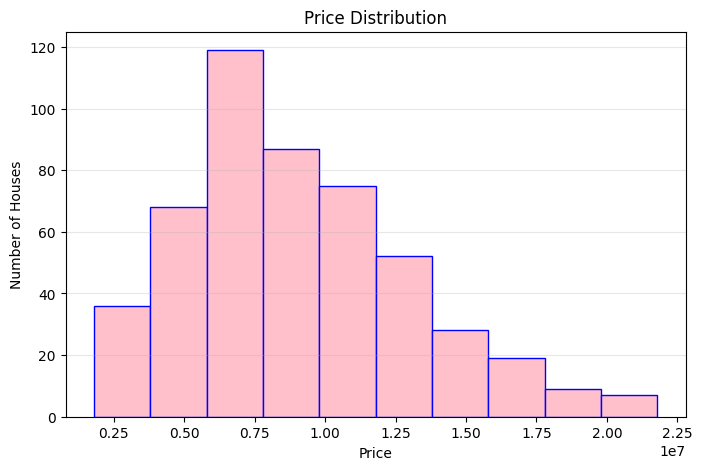

In [18]:
# Step 7 — Histogram: Price Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    df["Price"],
    bins=10,
    color="pink",
    edgecolor="blue"
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.grid(axis="y", alpha=0.3)

plt.show()

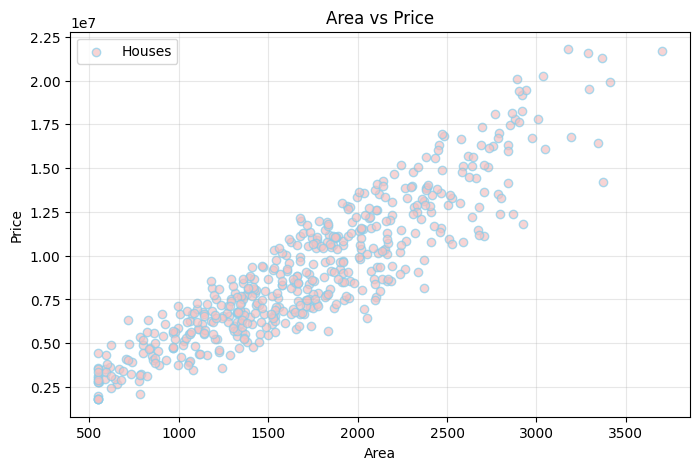

In [19]:
#Step 8 — Scatter Plot: Area vs Price
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area"],
    df["Price"],
    color="#F4C2C2",
    edgecolor="#87CEEB",
    alpha=0.7,
    label="Houses"
)

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

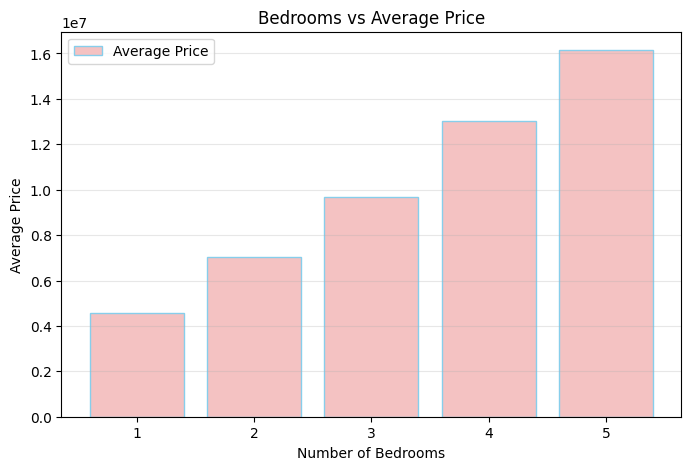

In [20]:
#Step 9 — Bedrooms vs Average Price
bedroom_avg = df.groupby("Bedrooms")["Price"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    bedroom_avg.index,
    bedroom_avg.values,
    color="#F4C2C2",
    edgecolor="#87CEEB",
    label="Average Price"
)

plt.title("Bedrooms vs Average Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

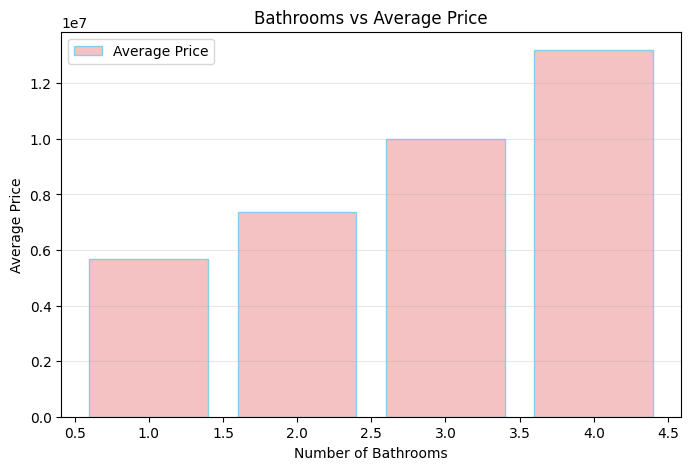

In [21]:
#Step 10 — Bathrooms vs Average Price
bathroom_avg = df.groupby("Bathrooms")["Price"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    bathroom_avg.index,
    bathroom_avg.values,
    color="#F4C2C2",
    edgecolor="#87CEEB",
    label="Average Price"
)

plt.title("Bathrooms vs Average Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Price")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

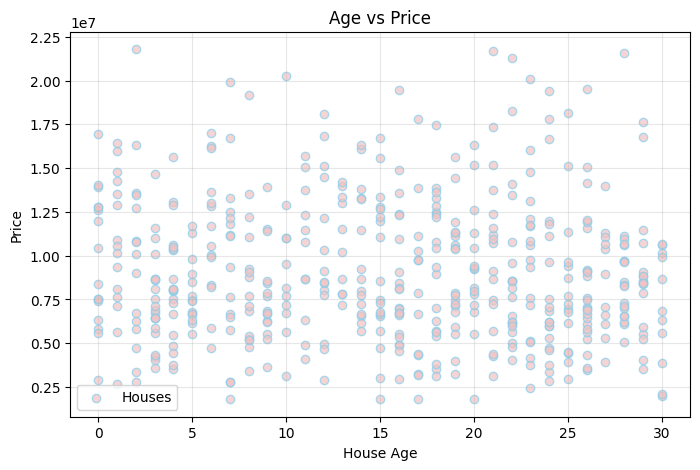

In [22]:
#Step 11 — Age vs Price
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Price"],
    color="#F4C2C2",
    edgecolor="#87CEEB",
    alpha=0.7,
    label="Houses"
)

plt.title("Age vs Price")
plt.xlabel("House Age")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

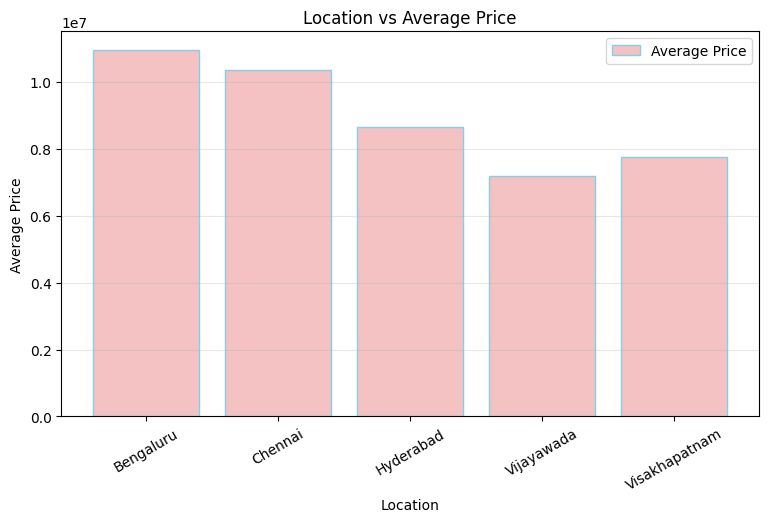

In [23]:
#Step 12 — Location vs Average Price
location_avg = df.groupby("Location")["Price"].mean()

plt.figure(figsize=(9, 5))

plt.bar(
    location_avg.index,
    location_avg.values,
    color="#F4C2C2",
    edgecolor="#87CEEB",
    label="Average Price"
)

plt.title("Location vs Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")

plt.xticks(rotation=30)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

C:\Users\VARSHA\AppData\Local\Temp\ipykernel_6384\1918126702.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


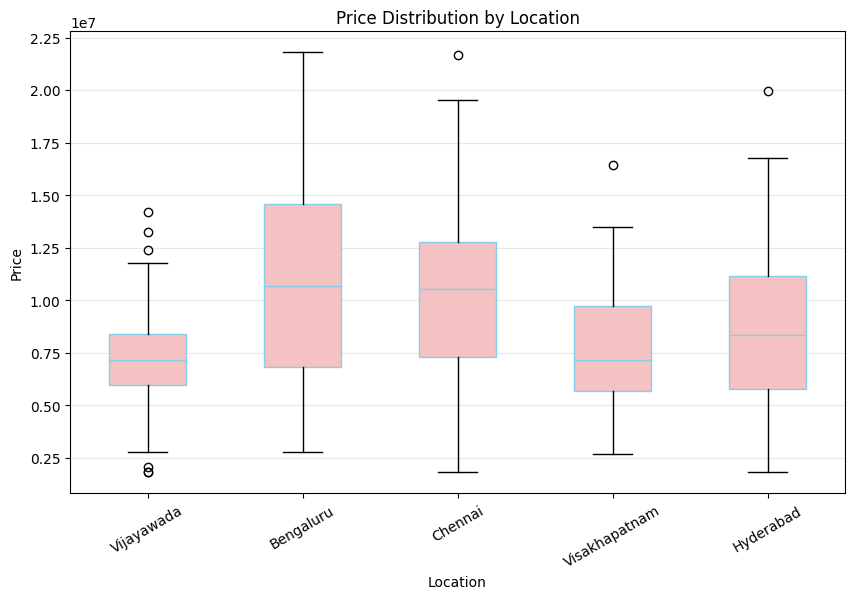

In [24]:
#Step 13 — Box Plot: Price by Location
locations = df["Location"].unique()

price_data = []

for location in locations:
    price_data.append(
        df[df["Location"] == location]["Price"]
    )

plt.figure(figsize=(10, 6))

box = plt.boxplot(
    price_data,
    labels=locations,
    patch_artist=True
)

for box_item in box["boxes"]:
    box_item.set_facecolor("#F4C2C2")
    box_item.set_edgecolor("#87CEEB")

for median in box["medians"]:
    median.set_color("#87CEEB")

plt.title("Price Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Price")

plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [25]:
#Step 14 — Most Expensive Property
most_expensive = df.loc[df["Price"].idxmax()]

print("Most Expensive Property:")
print(most_expensive)

Most Expensive Property:
Area              3176
Bedrooms             5
Bathrooms            4
Age                  2
Location     Bengaluru
Price         21791000
Name: 197, dtype: object


In [26]:
#Step 15 — Cheapest Property
cheapest = df.loc[df["Price"].idxmin()]

print("Cheapest Property:")
print(cheapest)


Cheapest Property:
Area                550
Bedrooms              1
Bathrooms             1
Age                   7
Location     Vijayawada
Price           1800000
Name: 180, dtype: object


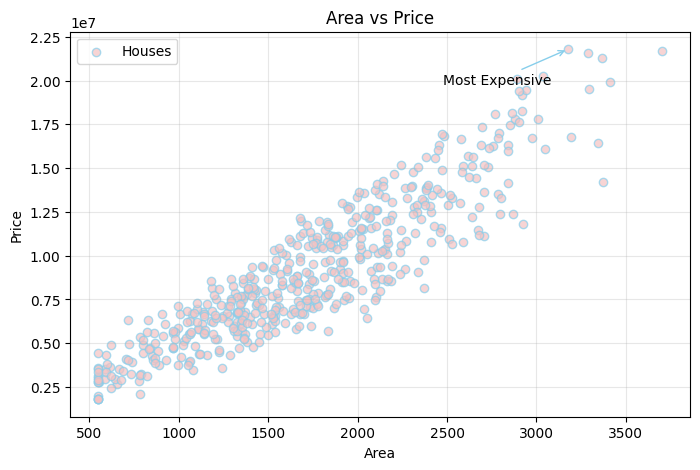

In [27]:
#Step 16 — Annotate Most Expensive Property
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area"],
    df["Price"],
    color="#F4C2C2",
    edgecolor="#87CEEB",
    alpha=0.7,
    label="Houses"
)

max_house = df.loc[df["Price"].idxmax()]

plt.annotate(
    "Most Expensive",
    xy=(max_house["Area"], max_house["Price"]),
    xytext=(
        max_house["Area"] - 700,
        max_house["Price"] - 2000000
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="#87CEEB"
    )
)

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

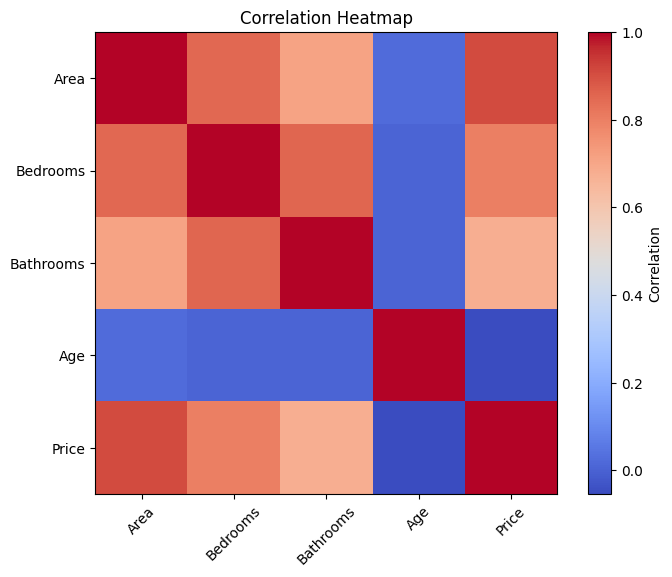

In [28]:
#Step 17 — Heatmap-Style Visualization
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap="coolwarm"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

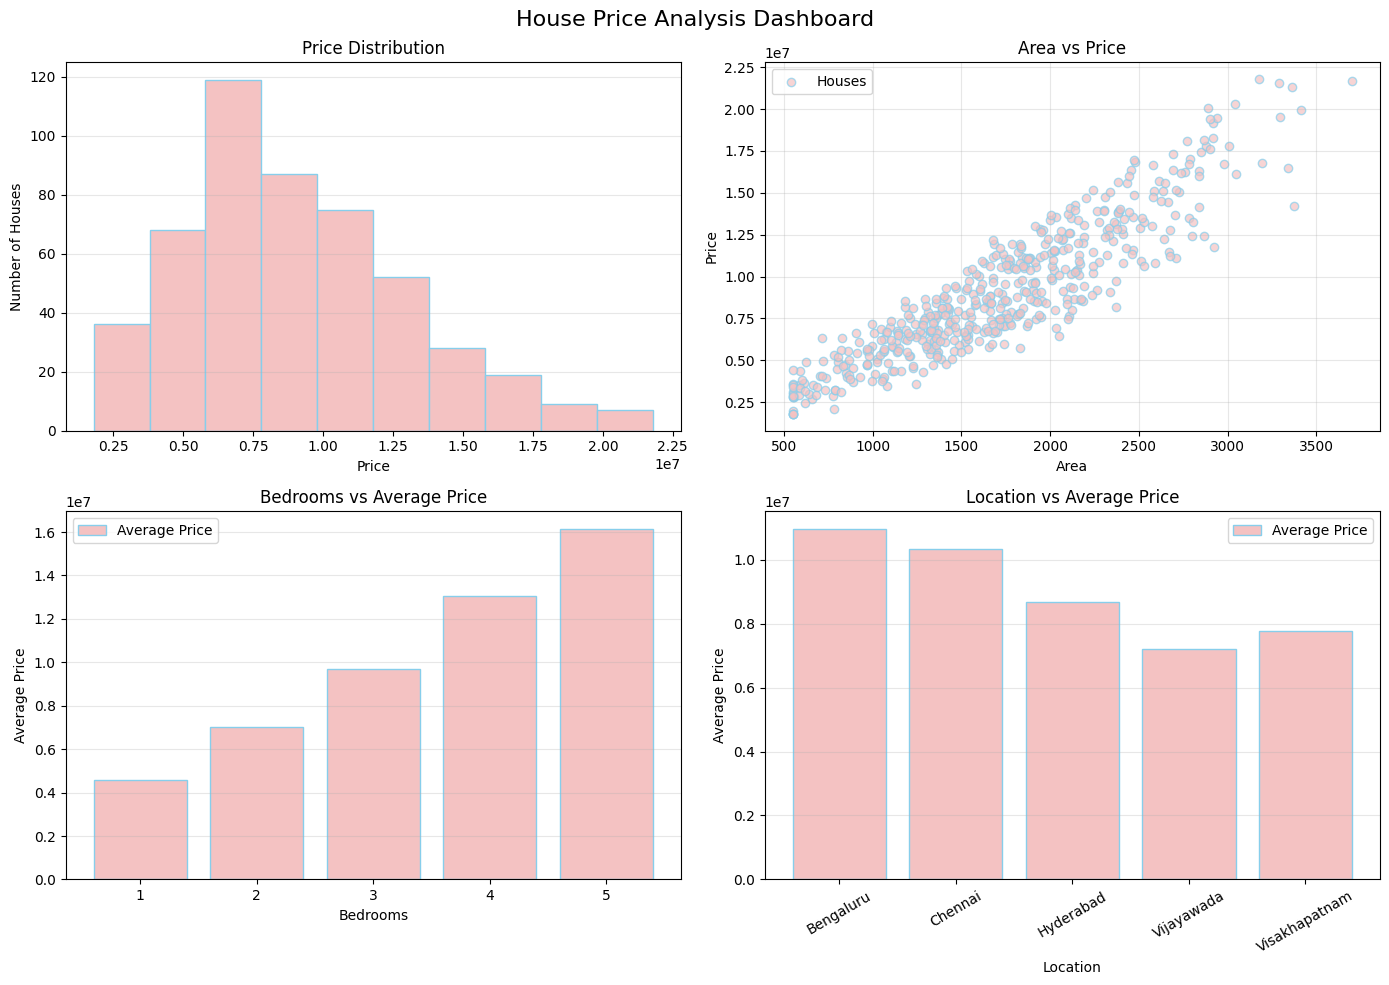

In [29]:
#Step 18 — 2 × 2 Dashboard
fig, ax = plt.subplots(2, 2, figsize=(14, 10))


# 1. Price Distribution
ax[0, 0].hist(
    df["Price"],
    bins=10,
    color="#F4C2C2",
    edgecolor="#87CEEB"
)

ax[0, 0].set_title("Price Distribution")
ax[0, 0].set_xlabel("Price")
ax[0, 0].set_ylabel("Number of Houses")
ax[0, 0].grid(axis="y", alpha=0.3)


# 2. Area vs Price
ax[0, 1].scatter(
    df["Area"],
    df["Price"],
    color="#F4C2C2",
    edgecolor="#87CEEB",
    alpha=0.7,
    label="Houses"
)

ax[0, 1].set_title("Area vs Price")
ax[0, 1].set_xlabel("Area")
ax[0, 1].set_ylabel("Price")
ax[0, 1].legend()
ax[0, 1].grid(True, alpha=0.3)


# 3. Bedrooms vs Average Price
bedroom_avg = df.groupby("Bedrooms")["Price"].mean()

ax[1, 0].bar(
    bedroom_avg.index,
    bedroom_avg.values,
    color="#F4C2C2",
    edgecolor="#87CEEB",
    label="Average Price"
)

ax[1, 0].set_title("Bedrooms vs Average Price")
ax[1, 0].set_xlabel("Bedrooms")
ax[1, 0].set_ylabel("Average Price")
ax[1, 0].legend()
ax[1, 0].grid(axis="y", alpha=0.3)


# 4. Location vs Average Price
location_avg = df.groupby("Location")["Price"].mean()

ax[1, 1].bar(
    location_avg.index,
    location_avg.values,
    color="#F4C2C2",
    edgecolor="#87CEEB",
    label="Average Price"
)

ax[1, 1].set_title("Location vs Average Price")
ax[1, 1].set_xlabel("Location")
ax[1, 1].set_ylabel("Average Price")

ax[1, 1].tick_params(axis="x", rotation=30)

ax[1, 1].legend()
ax[1, 1].grid(axis="y", alpha=0.3)


plt.suptitle(
    "House Price Analysis Dashboard",
    fontsize=16
)

plt.tight_layout()

plt.show()